<a href="https://colab.research.google.com/github/umyunsang/edu/blob/main/ComputerScience/03_ai-ml-data/quantum-ml/03.variational-learning-and-kernels/01.loss-and-optimization/09_cobyla_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Day21 COBYLA optimizer 실습

- Source: Google Drive `Day21/3-2.py`
- Runtime: Google Colab recommended. Do not install or execute dependencies locally for sync validation.


STEP 2. Parameterized Quantum Circuit
        ┌───────┐ ░ ┌─┐
     q: ┤ Ry(θ) ├─░─┤M├
        └───────┘ ░ └╥┘
meas: 1/═════════════╩═
                     0 


STEP 3. Aer Simulator
Backend : AerSimulator('aer_simulator')
Shots   : 2048


STEP 4. Prediction Function


STEP 5. Prediction Test


Theta : 0.000
Prediction : 1.0000
----------------------------------------


Theta : 1.571
Prediction : 0.0234
----------------------------------------


Theta : 3.142
Prediction : -1.0000
----------------------------------------


STEP 6. Target
Target : -0.8


STEP 7. Objective Function
Objective Function 생성 완료


STEP 8. Objective Function Test


Theta      : 0.100
Prediction : 0.9971
Loss       : 3.215437
--------------------------------------------------


Theta      : 1.000
Prediction : 0.5312
Loss       : 1.861732
--------------------------------------------------


Theta      : 2.500
Prediction : -0.8008
Loss       : 0.000003
--------------------------------------------------


STEP 9. Parameter Sweep


Parameter Sweep 완료
Total Samples : 30


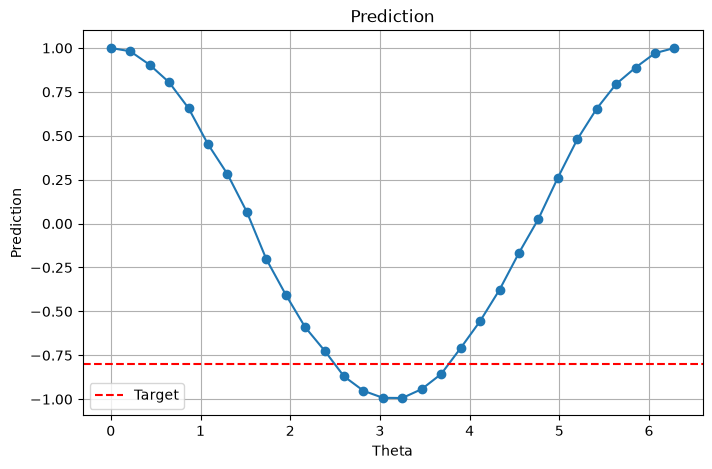

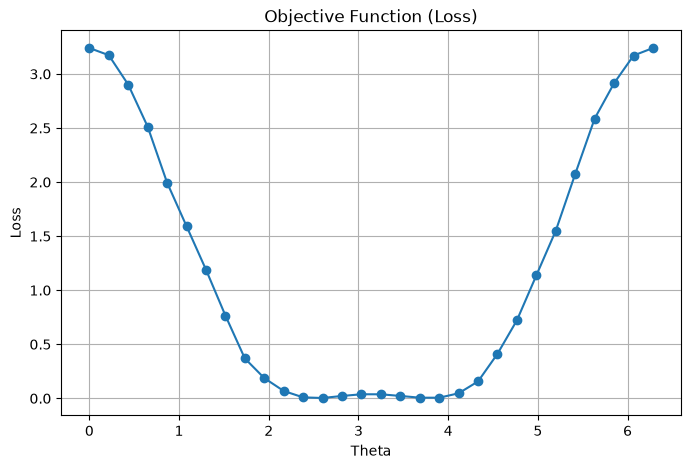



STEP 12. Best Parameter
Best Theta      : 2.5999
Prediction      : -0.8701
Target          : -0.8000
Loss            : 0.00318607
Lab Complete


STEP 2. Common Objective Function
Part 6의 Objective Function 재사용


STEP 3. COBYLA History


STEP 4. COBYLA Objective


STEP 5. Initial Parameter


Initial Parameter : 0.2
Initial Prediction : 0.9794921875
Initial Loss : 3.1665924453735355


STEP 6. COBYLA


STEP 7. Optimization
[001] Theta=  0.2000 Prediction=  0.9834 Loss=  3.180510


[002] Theta=  1.2000 Prediction=  0.3877 Loss=  1.410620
[003] Theta=  2.2000 Prediction= -0.5967 Loss=  0.041339


[004] Theta=  4.2000 Prediction= -0.5010 Loss=  0.089415
[005] Theta=  1.2000 Prediction=  0.3701 Loss=  1.369174


...

[025] Theta=  2.5000 Prediction= -0.8066 Loss=  0.000044
[026] Theta=  2.5000 Prediction= -0.7852 Loss=  0.000220


[027] Theta=  2.5000 Prediction= -0.8066 Loss=  0.000044
[028] Theta=  2.5000 Prediction= -0.7959 Loss=  0.000017


[029] Theta=  2.5000 Prediction= -0.8027 Loss=  0.000007
[030] Theta=  2.5000 Prediction= -0.7842 Loss=  0.000250


[031] Theta=  2.5000 Prediction= -0.7832 Loss=  0.000282
[032] Theta=  2.5000 Prediction= -0.8115 Loss=  0.000133


[033] Theta=  2.5000 Prediction= -0.8164 Loss=  0.000269


STEP 8. Result
Optimal Theta : 2.499995
Optimizer Loss : 7.476806640624757e-06
Function Evaluation : 33
Iteration : None
Elapsed Time : 5.089348332956433


STEP 9. Prediction Verification
Prediction : -0.7880859375
Target : -0.8
Verified Loss : 0.0001419448852539073


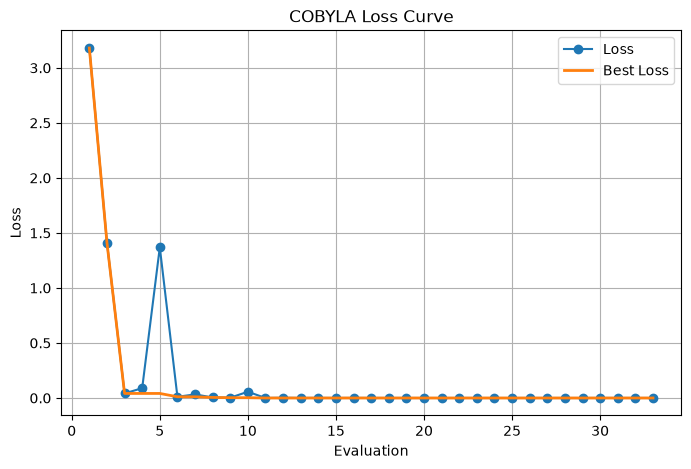

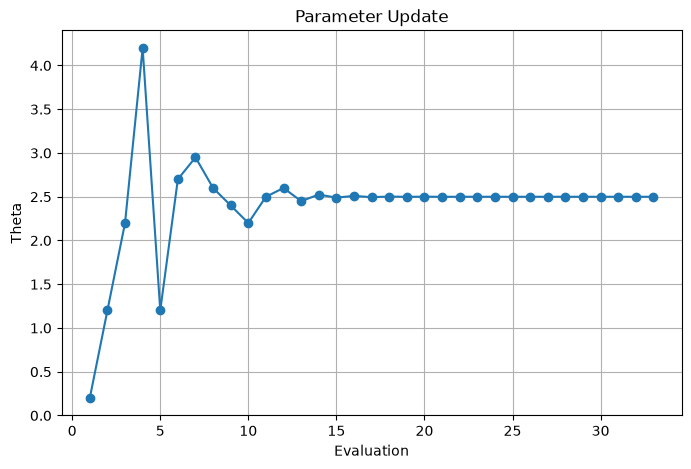

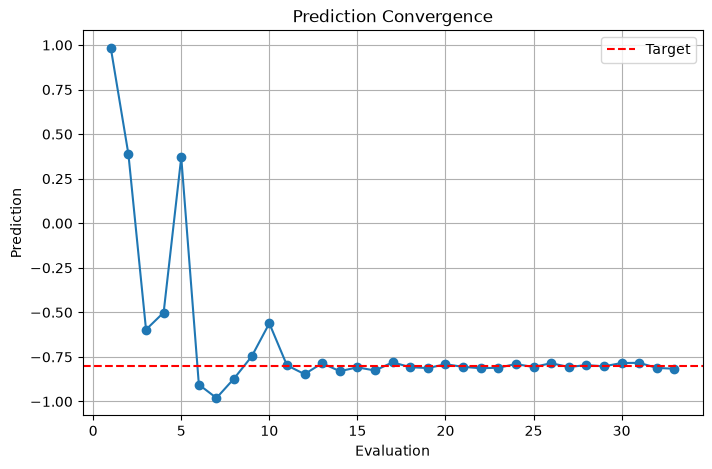

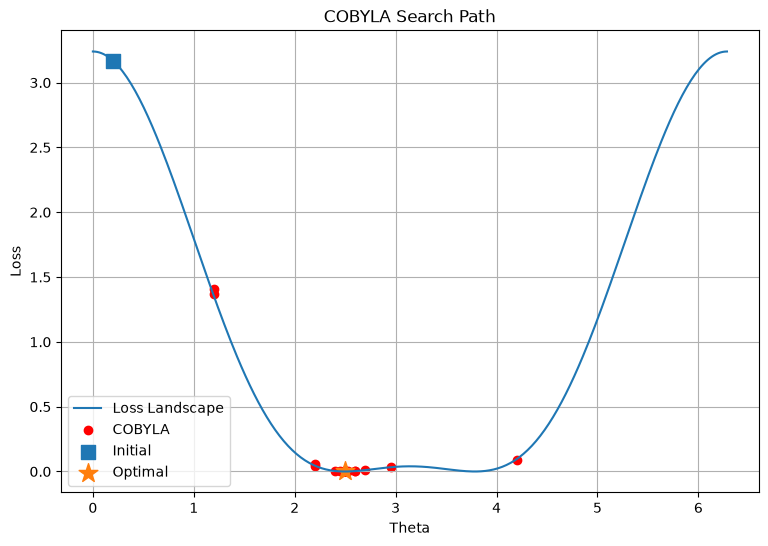



SUMMARY
Initial Parameter : 0.2
Optimal Parameter : 2.499995
Initial Loss : 3.1665924453735355
Final Loss : 0.0001419448852539073
Prediction : -0.7880859375
Function Evaluation : 33
Iteration : None

COBYLA는
Objective Function을 반복 호출하여
Loss가 가장 작은 Parameter를 탐색하였다.

Lab Complete


In [1]:
"""
============================================================
Lab 6-2. COBYLA Optimizer 적용
============================================================
"""


# ============================================================
# STEP 1. Library Import
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit import transpile

from qiskit.circuit import Parameter

from qiskit_aer import AerSimulator

# ============================================================
# STEP 2. Parameterized Quantum Circuit 생성
# ============================================================

print("=" * 80)
print("STEP 2. Parameterized Quantum Circuit")
print("=" * 80)

# 학습 대상 Parameter
theta = Parameter("θ")

# 1-Qubit Circuit
qc = QuantumCircuit(1)

# Parameterized Gate
qc.ry(theta, 0)

# Measurement
qc.measure_all()

print(qc.draw())

# ============================================================
# STEP 3. Quantum Simulator 준비
# ============================================================

print("\n")
print("=" * 80)
print("STEP 3. Aer Simulator")
print("=" * 80)

simulator = AerSimulator()

shots = 2048

print("Backend :", simulator)
print("Shots   :", shots)

# ============================================================
# STEP 4. Prediction Function 구현
# ============================================================

print("\n")
print("=" * 80)
print("STEP 4. Prediction Function")
print("=" * 80)


def predict(theta_value):
    """
    Parameter를 입력받아
    Quantum Circuit을 실행하고
    Prediction(Expectation Value)을 반환
    """

    # --------------------------------------
    # Parameter Binding
    # --------------------------------------

    bound = qc.assign_parameters(
        {theta: theta_value}
    )

    # --------------------------------------
    # Compile
    # --------------------------------------

    compiled = transpile(
        bound,
        simulator
    )

    # --------------------------------------
    # Run
    # --------------------------------------

    job = simulator.run(
        compiled,
        shots=shots
    )

    result = job.result()

    counts = result.get_counts()

    # --------------------------------------
    # Probability
    # --------------------------------------

    p0 = counts.get("0", 0) / shots
    p1 = counts.get("1", 0) / shots

    # --------------------------------------
    # Prediction
    #
    # <Z> = p0 - p1
    # --------------------------------------

    prediction = p0 - p1

    return prediction


# ============================================================
# STEP 5. Prediction Test
# ============================================================

print("\n")
print("=" * 80)
print("STEP 5. Prediction Test")
print("=" * 80)

test_angles = [
    0,
    np.pi / 2,
    np.pi
]

for angle in test_angles:

    pred = predict(angle)

    print(f"Theta : {angle:.3f}")
    print(f"Prediction : {pred:.4f}")
    print("-" * 40)

# ============================================================
# STEP 6. Target 설정
# ============================================================

print("\n")
print("=" * 80)
print("STEP 6. Target")
print("=" * 80)

target = -0.8

print("Target :", target)

# ============================================================
# STEP 7. Objective Function 구현
# ============================================================

print("\n")
print("=" * 80)
print("STEP 7. Objective Function")
print("=" * 80)


def objective(theta_value):
    """
    Optimizer가 호출할
    공통 Objective Function

    Input
    -----
    theta

    Output
    ------
    Loss
    """

    prediction = predict(theta_value)

    loss = (prediction - target) ** 2

    return loss


print("Objective Function 생성 완료")

# ============================================================
# STEP 8. Objective Function Test
# ============================================================

print("\n")
print("=" * 80)
print("STEP 8. Objective Function Test")
print("=" * 80)

test_parameters = [
    0.1,
    1.0,
    2.5
]

for theta_value in test_parameters:

    prediction = predict(theta_value)

    loss = objective(theta_value)

    print(f"Theta      : {theta_value:.3f}")
    print(f"Prediction : {prediction:.4f}")
    print(f"Loss       : {loss:.6f}")
    print("-" * 50)

# ============================================================
# STEP 9. Parameter Sweep
# ============================================================

print("\n")
print("=" * 80)
print("STEP 9. Parameter Sweep")
print("=" * 80)

angles = np.linspace(
    0,
    2 * np.pi,
    30
)

predictions = []

losses = []

for angle in angles:

    prediction = predict(angle)

    loss = objective(angle)

    predictions.append(prediction)

    losses.append(loss)

# 결과 출력

print("Parameter Sweep 완료")

print("Total Samples :", len(angles))

# ============================================================
# STEP 10. Prediction Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    angles,
    predictions,
    marker="o"
)

plt.axhline(
    y=target,
    color="red",
    linestyle="--",
    label="Target"
)

plt.title("Prediction")

plt.xlabel("Theta")

plt.ylabel("Prediction")

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# STEP 11. Loss Graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    angles,
    losses,
    marker="o"
)

plt.title("Objective Function (Loss)")

plt.xlabel("Theta")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

# ============================================================
# STEP 12. Best Parameter 찾기
# ============================================================

print("\n")
print("=" * 80)
print("STEP 12. Best Parameter")
print("=" * 80)

best_index = np.argmin(losses)

best_theta = angles[best_index]

best_prediction = predictions[best_index]

best_loss = losses[best_index]

print(f"Best Theta      : {best_theta:.4f}")

print(f"Prediction      : {best_prediction:.4f}")

print(f"Target          : {target:.4f}")

print(f"Loss            : {best_loss:.8f}")


print("=" * 80)
print("Lab Complete")
print("=" * 80)





# ============================================================
# STEP 1. Library Import
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt

from qiskit_algorithms.optimizers import COBYLA

# ============================================================
# STEP 2. Part 6 코드 준비
# ============================================================

"""
Part 6에서 다음 객체들이 이미 생성되어 있다고 가정한다.

theta
qc
predict()
target
shots
simulator
"""

print("="*80)
print("STEP 2. Common Objective Function")
print("="*80)

print("Part 6의 Objective Function 재사용")

# ============================================================
# STEP 3. COBYLA History
# ============================================================

print("\n")
print("="*80)
print("STEP 3. COBYLA History")
print("="*80)

cobyla_history = {

    "evaluation": [],

    "parameter": [],

    "prediction": [],

    "loss": [],

    "best_loss": []

}

# ============================================================
# STEP 4. COBYLA Objective Function
# ============================================================

print("\n")
print("="*80)
print("STEP 4. COBYLA Objective")
print("="*80)


def cobyla_objective(parameters):

    theta_value = float(parameters[0])

    prediction = predict(theta_value)

    loss = (prediction-target)**2

    evaluation = len(
        cobyla_history["evaluation"]
    ) + 1

    cobyla_history["evaluation"].append(
        evaluation
    )

    cobyla_history["parameter"].append(
        theta_value
    )

    cobyla_history["prediction"].append(
        prediction
    )

    cobyla_history["loss"].append(
        loss
    )

    current_best = min(
        cobyla_history["loss"]
    )

    cobyla_history["best_loss"].append(
        current_best
    )

    print(
        f"[{evaluation:03d}] "
        f"Theta={theta_value:8.4f} "
        f"Prediction={prediction:8.4f} "
        f"Loss={loss:10.6f}"
    )

    return float(loss)

# ============================================================
# STEP 5. Initial Parameter
# ============================================================

print("\n")
print("="*80)
print("STEP 5. Initial Parameter")
print("="*80)

initial_point = np.array([0.2])

initial_prediction = predict(
    initial_point[0]
)

initial_loss = (
    initial_prediction-target
)**2

print("Initial Parameter :", initial_point[0])

print("Initial Prediction :", initial_prediction)

print("Initial Loss :", initial_loss)

# ============================================================
# STEP 6. COBYLA 생성
# ============================================================

print("\n")
print("="*80)
print("STEP 6. COBYLA")
print("="*80)

optimizer = COBYLA(

    maxiter=100,

    rhobeg=1.0,

    tol=1e-6

)

print(optimizer)

# ============================================================
# STEP 7. Optimization
# ============================================================

print("\n")
print("="*80)
print("STEP 7. Optimization")
print("="*80)

start = time.perf_counter()

result = optimizer.minimize(

    fun=cobyla_objective,

    x0=initial_point

)

elapsed = time.perf_counter()-start

# ============================================================
# STEP 8. Optimization Result
# ============================================================

print("\n")
print("="*80)
print("STEP 8. Result")
print("="*80)

optimal_theta = float(result.x[0])

optimizer_loss = float(result.fun)

nfev = getattr(result,"nfev",None)

nit = getattr(result,"nit",None)

print("Optimal Theta :", optimal_theta)

print("Optimizer Loss :", optimizer_loss)

print("Function Evaluation :", nfev)

print("Iteration :", nit)

print("Elapsed Time :", elapsed)

# ============================================================
# STEP 9. Prediction Verification
# ============================================================

print("\n")
print("="*80)
print("STEP 9. Prediction Verification")
print("="*80)

final_prediction = predict(
    optimal_theta
)

verified_loss = (
    final_prediction-target
)**2

print("Prediction :", final_prediction)

print("Target :", target)

print("Verified Loss :", verified_loss)

# ============================================================
# STEP 10. Loss Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    cobyla_history["evaluation"],

    cobyla_history["loss"],

    marker="o",

    label="Loss"

)

plt.plot(

    cobyla_history["evaluation"],

    cobyla_history["best_loss"],

    linewidth=2,

    label="Best Loss"

)

plt.xlabel("Evaluation")

plt.ylabel("Loss")

plt.title("COBYLA Loss Curve")

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# STEP 11. Parameter Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    cobyla_history["evaluation"],

    cobyla_history["parameter"],

    marker="o"

)

plt.xlabel("Evaluation")

plt.ylabel("Theta")

plt.title("Parameter Update")

plt.grid(True)

plt.show()

# ============================================================
# STEP 12. Prediction Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    cobyla_history["evaluation"],

    cobyla_history["prediction"],

    marker="o"

)

plt.axhline(

    y=target,

    color="red",

    linestyle="--",

    label="Target"

)

plt.xlabel("Evaluation")

plt.ylabel("Prediction")

plt.title("Prediction Convergence")

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# STEP 13. Loss Landscape
# ============================================================

theta_space = np.linspace(
    0,
    2*np.pi,
    300
)

landscape = (
    np.cos(theta_space)-target
)**2

plt.figure(figsize=(9,6))

plt.plot(

    theta_space,

    landscape,

    label="Loss Landscape"

)

plt.scatter(

    cobyla_history["parameter"],

    cobyla_history["loss"],

    color="red",

    label="COBYLA"

)

plt.scatter(

    [initial_point[0]],

    [initial_loss],

    marker="s",

    s=100,

    label="Initial"

)

plt.scatter(

    [optimal_theta],

    [optimizer_loss],

    marker="*",

    s=200,

    label="Optimal"

)

plt.xlabel("Theta")

plt.ylabel("Loss")

plt.title("COBYLA Search Path")

plt.grid(True)

plt.legend()

plt.show()

# ============================================================
# STEP 14. Summary
# ============================================================

print("\n")
print("="*80)
print("SUMMARY")
print("="*80)

print("Initial Parameter :", initial_point[0])

print("Optimal Parameter :", optimal_theta)

print("Initial Loss :", initial_loss)

print("Final Loss :", verified_loss)

print("Prediction :", final_prediction)

print("Function Evaluation :", nfev)

print("Iteration :", nit)

print()

print("COBYLA는")

print("Objective Function을 반복 호출하여")

print("Loss가 가장 작은 Parameter를 탐색하였다.")

print()


print("="*80)
print("Lab Complete")
print("="*80)
